# Библиотеки

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import pingouin as pg
import seaborn as sns

## 10.3 Корреляции

- столбец Анкета - идентификатор, снесите его в индекс .set_index() чтобы в датафрейме остались только 3 числовые столбца
- столбец РаботаМаг - общая оценка магазина оценивается от 1 до 10 баллов
- столбец КачОбсл - оценка удовлетворенности обслуживанием в магазине также от 1 до 10 баллов
- столбец Ассортимент - оценка удовлетворенности широтой ассортимента в магазине также от 1 до 10 баллов

In [2]:
d = pd.read_excel('./data/SPSS21.xlsx')

In [3]:
d.head(3)

,Анкета,РаботаМаг,КачОбсл,Ассортимент
0,58,10,8,3
1,64,7,6,10
2,65q,3,3,3


In [4]:
d = d.set_index('Анкета')

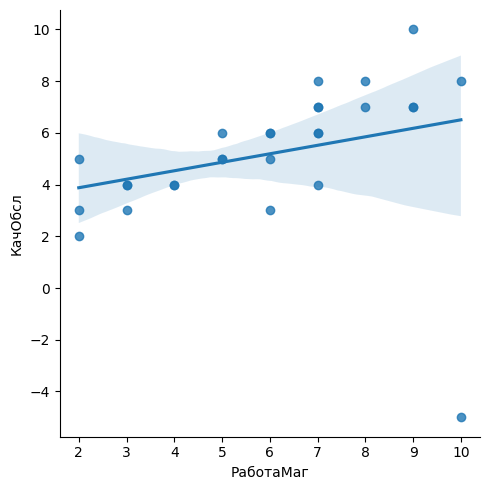

In [5]:
sns.lmplot(data=d, x='РаботаМаг', y='КачОбсл')

In [6]:
pd.concat([
    pg.corr(d['РаботаМаг'], d['КачОбсл'], method='pearson'),
    pg.corr(d['РаботаМаг'], d['КачОбсл'], method='spearman'),
    pg.corr(d['РаботаМаг'], d['КачОбсл'], method='kendall'),
    pg.corr(d['РаботаМаг'], d['КачОбсл'], method='shepherd')
          ])

,n,r,CI95%,p-val,BF10,power,outliers
pearson,28,0.291106,"[-0.09, 0.6]",1.328577e-01,0.688,0.330631,NaN
spearman,28,0.650992,"[0.37, 0.82]",1.758450e-04,NaN,0.976188,NaN
kendall,28,0.592944,"[0.28, 0.79]",4.813229e-05,NaN,0.933349,NaN
shepherd,28,0.837781,"[0.67, 0.92]",4.998470e-08,NaN,0.999975,1.0


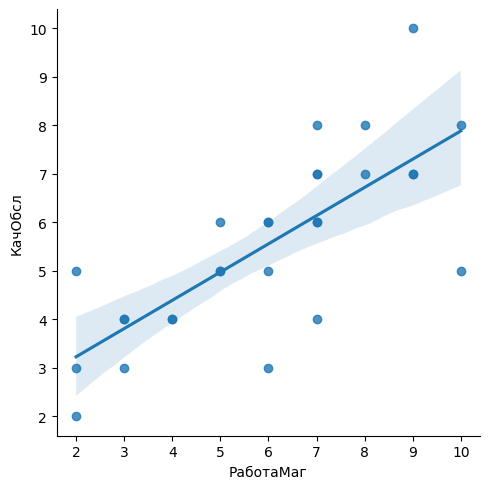

In [7]:
sns.lmplot(data=d.abs(), x='РаботаМаг', y='КачОбсл')

In [8]:
pg.corr(d['РаботаМаг'], d['КачОбсл'].abs(), method='pearson')

,n,r,CI95%,p-val,BF10,power
pearson,28,0.753146,"[0.53, 0.88]",0.000004,5961.322,0.998676


In [9]:
pg.normality(data=d.abs(), method='shapiro', alpha=0.05)

,W,pval,normal
РаботаМаг,0.948164,0.178112,True
КачОбсл,0.968296,0.535717,True
Ассортимент,0.869892,0.002422,False


## 10.6 Мидквел: корреляционная красота

In [23]:
d = d.abs()

In [24]:
z = d.corr()

<Axes: >

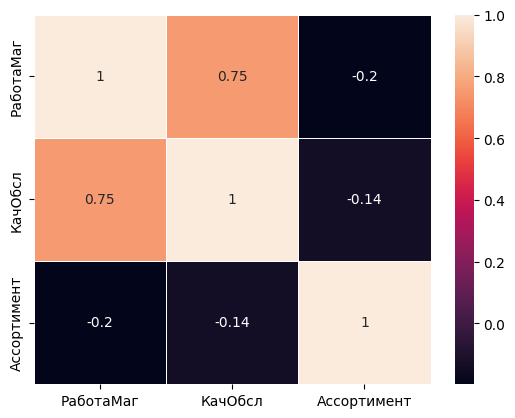

In [25]:
sns.heatmap(z, annot=True, linewidth=.5)

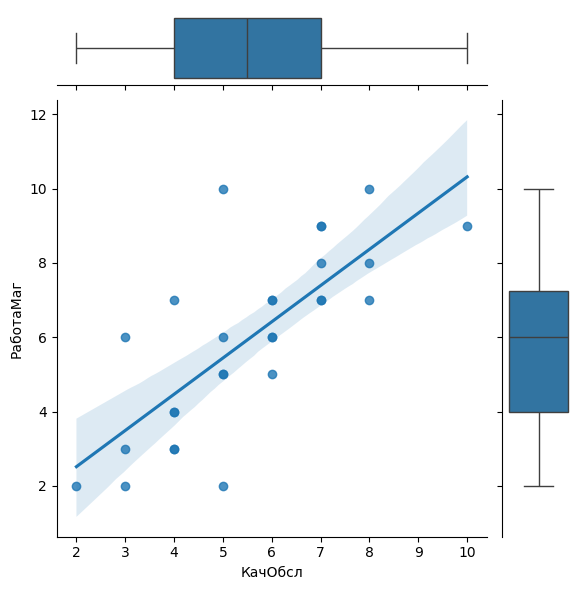

In [33]:
sns.JointGrid(data=d, x='КачОбсл', y='РаботаМаг').plot(sns.regplot, sns.boxplot)

In [27]:
d['АссУр'] = pd.cut(d['Ассортимент'], bins=[0, 5, 10], labels=['Ниже среднего', 'Выше среднего'], right=True)

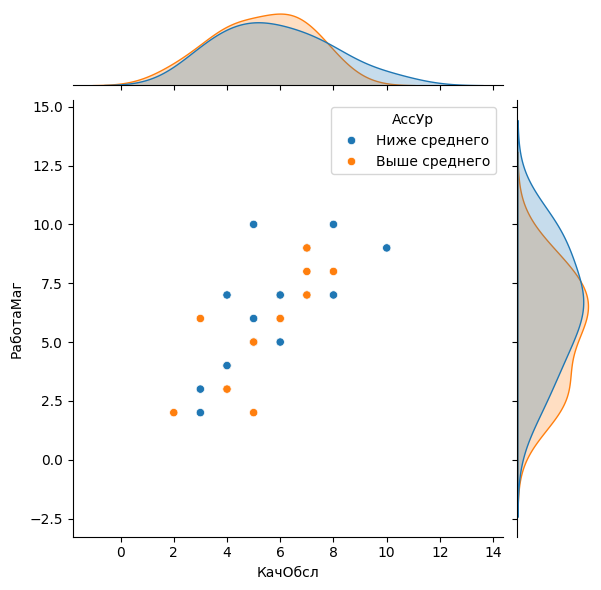

In [28]:
sns.jointplot(data=d, x='КачОбсл', y='РаботаМаг', hue='АссУр')